In [1]:
!pip install einops albumentations torchinfo

In [2]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"


import warnings
warnings.filterwarnings("ignore")

In [3]:
BATCH_SIZE = 64

LATENT_DIM = 128

EPOCHS = 5

LR = 0.001

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

NORMAL_CLASS = 0

train_images = []

for img, label in trainset:
    if label == NORMAL_CLASS:
        train_images.append(img)

train_loader = torch.utils.data.DataLoader(
    train_images,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    testset,
    batch_size=1,
    shuffle=True
)

print("Normal Training Images:", len(train_images))

100%|██████████| 170M/170M [49:09<00:00, 57.8kB/s]


Normal Training Images: 5000


In [5]:
class AutoEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64,LATENT_DIM,3,padding=1),

            nn.ReLU()

        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(LATENT_DIM,64,2,stride=2),

            nn.ReLU(),

            nn.ConvTranspose2d(64,32,2,stride=2),

            nn.ReLU(),

            nn.Conv2d(32,3,3,padding=1),

            nn.Sigmoid()

        )

    def forward(self,x):

        latent = self.encoder(x)

        reconstructed = self.decoder(latent)

        return reconstructed

In [6]:
model = AutoEncoder().to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)

criterion = nn.MSELoss()

In [7]:
def ssim_loss(original, reconstructed):

    original = original.detach().cpu().numpy()

    reconstructed = reconstructed.detach().cpu().numpy()

    score = 0

    for i in range(original.shape[0]):

        score += ssim(
            np.transpose(original[i], (1,2,0)),
            np.transpose(reconstructed[i], (1,2,0)),
            channel_axis=2,
            data_range=1.0
        )

    score /= original.shape[0]

    return 1-score

In [10]:
model.eval()

image, label = next(iter(test_loader))

image = image.to(device)

with torch.no_grad():

    reconstructed = model(image)


In [11]:
error = torch.abs(image - reconstructed)

error_map = error.squeeze().mean(0).cpu().numpy()

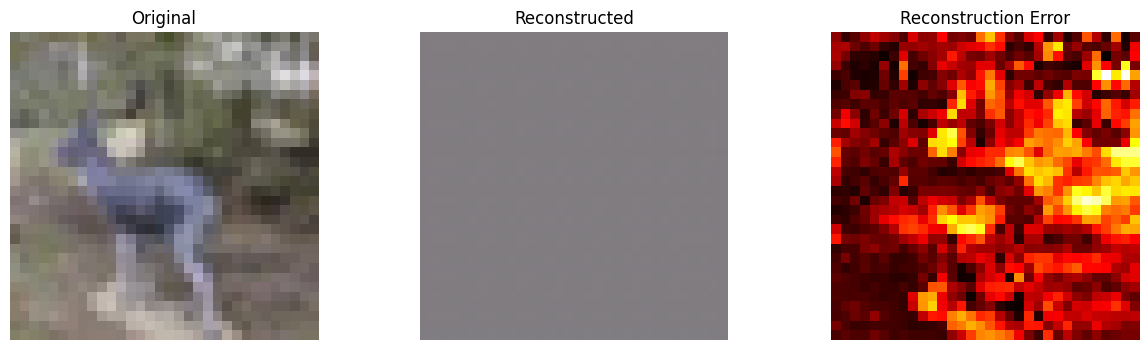

Actual Label: 4
Task 12 Completed Successfully!


In [12]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)

plt.imshow(image.squeeze().permute(1,2,0).cpu())

plt.title("Original")

plt.axis("off")

plt.subplot(1,3,2)

plt.imshow(reconstructed.squeeze().permute(1,2,0).cpu())

plt.title("Reconstructed")

plt.axis("off")

plt.subplot(1,3,3)

plt.imshow(error_map,cmap="hot")

plt.title("Reconstruction Error")

plt.axis("off")

plt.show()

print("Actual Label:",label.item())

print("Task 12 Completed Successfully!")